# Prediksi Harga Rumah

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Buat Dataset sintesis

In [5]:
np.random.seed(42)
n = 100

luas = np.random.randint(40, 200, n)
kamar = np.random.randint(1, 6, n)
harga = 200 + 2.5*luas + 15*kamar + np.random.normal(0, 20, n)

df = pd.DataFrame({'luas_m2': luas, 'jumlah_kamar': kamar, 'harga_juta': harga})
print("5 data pertama:")
print(df.head())

5 data pertama:
   luas_m2  jumlah_kamar  harga_juta
0      142             5  668.676796
1      132             3  576.619416
2       54             4  386.670873
3      146             3  627.150065
4      111             3  536.862566


# Split train/test

In [6]:
X = df[['luas_m2', 'jumlah_kamar']]
y = df['harga_juta']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training model

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"\nIntercept (β₀) : {model.intercept_:.2f}")
print(f"Koefisien luas : {model.coef_[0]:.2f}")
print(f"Koefisien kamar : {model.coef_[1]:.2f}")


Intercept (β₀) : 197.21
Koefisien luas : 2.51
Koefisien kamar : 14.98


# Evaluasi

In [14]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMSE  : {mse:.2f}")
print(f"RMSE : {np.sqrt(mse):.2f}")
print(f"R²   : {r2:.4f}  (semakin mendekati 1 = semakin baik)")


MSE  : 446.54
RMSE : 21.13
R²   : 0.9606  (semakin mendekati 1 = semakin baik)


# Prediksi baru

In [10]:
rumah_baru = pd.DataFrame({'luas_m2': [120], 'jumlah_kamar': [3]})
prediksi = model.predict(rumah_baru)
print(f"\nPrediksi harga rumah 120m2/3 kamar: Rp{prediksi[0]:.1f} juta")


Prediksi harga rumah 120m2/3 kamar: Rp542.8 juta


# Visualisasi

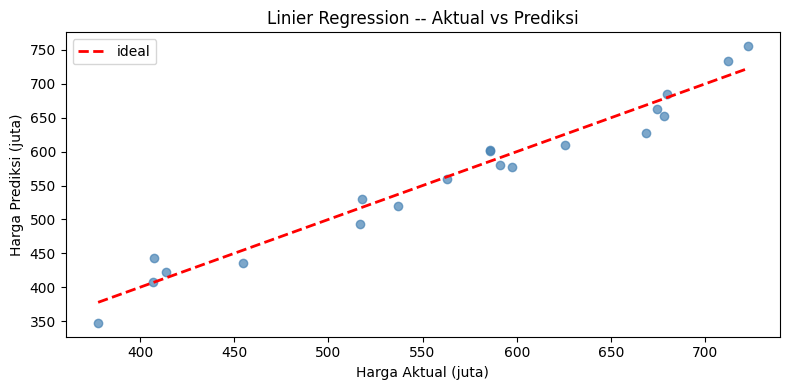

(None, None)

In [15]:
plt.figure(figsize=(8,4))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'r--', lw=2, label='ideal')
plt.xlabel('Harga Aktual (juta)')
plt.ylabel('Harga Prediksi (juta)')
plt.title('Linier Regression -- Aktual vs Prediksi')
plt.legend(); plt.tight_layout(), plt.show()
    